In [9]:
# ----------------------------------------------------------------------------
# Title: Assignment 4.2
# Author: Surenther Selvaraj
# Date: 15 Jan 2026
# Modified By: Surenther Selvaraj
# Description: R/Python Refresher
# ----------------------------------------------------------------------------

#### Step 1: Data Loading and Clinical Feature Selection
In this step, the ALS patient dataset is loaded, and administrative identifiers—specifically ID and SubjectID—are removed. These columns are unique to each record and do not provide any clinical or biological insight into the patient's condition. By excluding them, the clustering model can focus exclusively on medical parameters such as age, blood chemistry (e.g., Albumin, Creatinine), and disease progression scores (ALSFRS).

In [10]:
import pandas as pd

df = pd.read_csv('als_data.csv')
df_cleaned = df.drop(columns=['ID', 'SubjectID'])
df_cleaned.head()

,Age_mean,Albumin_max,Albumin_median,Albumin_min,Albumin_range,ALSFRS_slope,ALSFRS_Total_max,ALSFRS_Total_median,ALSFRS_Total_min,ALSFRS_Total_range,...,Sodium_median,Sodium_min,Sodium_range,trunk_max,trunk_median,trunk_min,trunk_range,Urine.Ph_max,Urine.Ph_median,Urine.Ph_min
0,65,57.0,40.5,38.0,0.066202,-0.965608,30,28.0,22,0.021164,...,145.5,143.0,0.017422,8,7.0,7,0.002646,6.0,6.0,6.0
1,48,45.0,41.0,39.0,0.010453,-0.921717,37,33.0,21,0.028725,...,138.0,136.0,0.010453,8,7.0,5,0.005386,7.0,5.0,5.0
2,38,50.0,47.0,45.0,0.008929,-0.914787,24,14.0,10,0.025000,...,143.0,140.0,0.008929,5,0.0,0,0.008929,6.0,5.0,5.0
3,63,47.0,44.0,41.0,0.012111,-0.598361,30,29.0,24,0.014963,...,139.0,138.0,0.012469,5,5.0,3,0.004988,7.0,6.0,5.0
4,63,47.0,45.5,42.0,0.008292,-0.444039,32,27.5,20,0.020374,...,140.0,138.0,0.008292,6,4.0,1,0.008489,6.0,5.0,5.0


#### Step 2: Feature Scaling using Standard Scaler
This step involves normalizing the clinical features so that each variable has a mean of 0 and a standard deviation of 1. Since clustering algorithms are sensitive to the scale of the data, this transformation ensures that features with large numerical ranges (such as Platelets) do not dominate features with smaller ranges (such as ALSFRS_slope) during distance calculations.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_cleaned), columns=df_cleaned.columns)
df_scaled.head()

,Age_mean,Albumin_max,Albumin_median,Albumin_min,Albumin_range,ALSFRS_slope,ALSFRS_Total_max,ALSFRS_Total_median,ALSFRS_Total_min,ALSFRS_Total_range,...,Sodium_median,Sodium_min,Sodium_range,trunk_max,trunk_median,trunk_min,trunk_range,Urine.Ph_max,Urine.Ph_median,Urine.Ph_min
0,0.917137,3.089417,-1.300781,-0.866550,5.480929,-0.381450,-0.318520,0.134960,0.247368,-0.301588,...,2.992342,2.300470,0.260968,1.028018,0.981832,1.715365,-0.997420,-0.880376,0.463054,1.868532
1,-0.574879,-0.622016,-1.112401,-0.553303,-0.347725,-0.310907,0.998995,0.888863,0.130839,0.166537,...,-1.198812,-0.278144,-0.489913,1.028018,0.981832,0.867032,-0.388669,0.192665,-1.137208,-0.419151
2,-1.452535,0.924415,1.148162,1.326179,-0.507103,-0.299769,-1.447819,-1.975969,-1.150976,-0.064100,...,1.595291,1.195350,-0.654169,-0.688950,-2.280669,-1.253800,0.398249,-0.880376,-1.137208,-0.419151
3,0.741606,-0.003443,0.017880,0.073191,-0.174361,0.208801,-0.318520,0.285741,0.480425,-0.685524,...,-0.639992,0.458603,-0.272701,-0.688950,0.049689,0.018699,-0.477181,0.192665,0.463054,-0.419151
4,0.741606,-0.003443,0.583021,0.386438,-0.573670,0.456831,0.057913,0.059570,0.014311,-0.350529,...,-0.081171,0.458603,-0.722774,-0.116627,-0.416383,-0.829634,0.300598,-0.880376,-1.137208,-0.419151


#### Step 3: Silhouette Score Analysis for Optimal Clusters

This step calculates the silhouette score for a range of cluster counts (from 2 to 10) to evaluate the quality of the K-means clustering. The silhouette score measures how well each data point fits within its assigned cluster compared to other clusters, with a higher score indicating better-defined clusters. The resulting plot helps in identifying the "optimal" number of clusters where the score is maximized.

Text(0.5, 1.0, 'Silhouette Score vs. Number of Clusters')

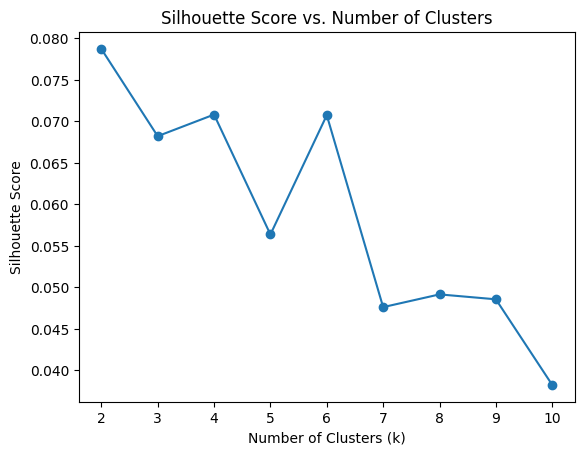

In [12]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Range of clusters to evaluate
range_n_clusters = range(2, 11)
silhouette_avg_scores = []

# Calculate silhouette score for each k
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_scaled)
    silhouette_avg = silhouette_score(df_scaled, cluster_labels)
    silhouette_avg_scores.append(silhouette_avg)

# Create the plot
plt.plot(range_n_clusters, silhouette_avg_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')

#### Step 4: Understading from Silhouette Score
The silhouette score suggests that dividing the ALS dataset into two clusters (k = 2) produces the strongest result, with the highest level of internal consistency. After this point, cluster quality generally decreases as more clusters are added, although smaller improvements appear at k = 4 and k = 6. Overall, silhouette scores are low across all values of k (remaining below 0.08), which indicates that the clinical variables do not separate cleanly into distinct groups. When the number of clusters exceeds six, performance drops more noticeably, reaching its lowest value at k = 10. Taken together, these results suggest that while a two-cluster solution performs best statistically, the underlying structure of the dataset is complex and does not exhibit well-defined cluster boundaries.

#### Step 5: K-means Model Fitting with Optimal Clusters

This step involves initializing the K-means algorithm with the optimal number of clusters (k=2) identified from the silhouette analysis. The model is then fitted to the standardized dataset, which assigns each patient to one of the two clusters based on the mathematical similarity of their clinical attributes.

In [13]:
from sklearn.cluster import KMeans


optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

df_cleaned['Cluster'] = clusters
print(df_cleaned['Cluster'].value_counts())

Cluster
1    1112
0    1111
Name: count, dtype: int64


#### Step 6 : PCA Dimensionality Reduction

This step involves applying Principal Component Analysis (PCA) to reduce the high-dimensional clinical dataset into two primary components. By transforming the data into a 2D space, we can simplify the complexity of the medical features while preserving as much variance as possible, which facilitates the visualization of the clusters formed in the previous step.

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(data=pca_data, columns=['PCA1', 'PCA2'])
df_pca.head()

,PCA1,PCA2
0,1.426731,-2.319374
1,1.440235,-4.871672
2,-1.617855,-0.429015
3,1.919998,2.095630
4,-0.297704,0.167252


#### Visualizing Clusters with PCA

In this step, the PCA-transformed data is visualized using a scatterplot. Each point represents an ALS patient, projected onto the two primary axes of variance (PCA1 and PCA2). The points are colored according to their K-means cluster assignment (k=2), allowing us to see how the mathematical groupings identified by the algorithm align with the visual structure of the dataset in a reduced two-dimensional space.

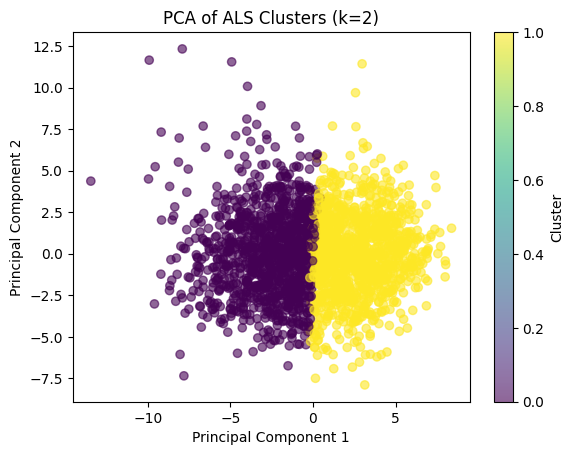

In [15]:
import matplotlib.pyplot as plt

df_pca['Cluster'] = clusters

plt.scatter(df_pca['PCA1'], df_pca['PCA2'], c=df_pca['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of ALS Clusters (k=2)')
plt.colorbar(label='Cluster')

#### Summary 
The analysis of the ALS patient dataset demonstrates that the clinical and physiological features are most effectively grouped into two distinct clusters (k=2). Although the silhouette scores remained relatively low, suggesting a high degree of overlap and complexity in the patients' medical profiles, k=2 provided the strongest statistical separation for the cohort. By reducing the data into two principal components via PCA, we were able to visualize these clusters, revealing a primary axis of variance that separates the patient population. The results indicate that while there are underlying patterns in disease progression and blood chemistry, ALS symptoms and markers exist on a broad spectrum rather than in isolated categories. Ultimately, these clusters could serve as a foundation for further research into how different patient subgroups respond to treatments or how their conditions progress over time.